# 10 — Simulated A/B Testing: Impact of Income Prediction on Budget Planning Accuracy
**Fingo Income Predictor** | Tim CC26-PSU217

> ⚠️ **Catatan Penting:** Notebook ini menggunakan **synthetic dataset** untuk mensimulasikan
> pipeline evaluasi fitur **Income Predictor** yang mendukung **Budget Planner adaptif** Fingo.
> Seluruh hasil harus diinterpretasikan sebagai **proof-of-concept**, bukan sebagai bukti
> kausalitas atau efektivitas fitur di dunia nyata.

---

### Tujuan Analisis
Menguji apakah pengguna yang mendapatkan bantuan **prediksi income** dan **rekomendasi budget adaptif**
menghasilkan perencanaan anggaran yang **lebih akurat** dibandingkan pengguna yang membuat budget manual
berdasarkan rata-rata income historis.

> Income Predictor tidak secara langsung mengubah perilaku pengeluaran user, melainkan membantu
> menghasilkan planned budget yang lebih mendekati kemampuan finansial aktual (actual income).

### Desain Eksperimen
| Elemen | Deskripsi |
|--------|-----------|
| **Control Group** | Budget manual berdasarkan rolling mean 4 minggu income historis |
| **Treatment Group** | Budget adaptif berdasarkan predicted income dari Income Predictor |
| **Assignment** | Stratified random 50:50 berdasarkan `gig_type` |
| **Primary Metric** | `mean_budget_error` — rata-rata selisih absolut antara planned budget dan ideal budget (actual_income × BUDGET_RATIO) |
| **Secondary Metrics** | `budget_adherence_rate`, `over_budget_rate`, `expense_to_income_ratio`, `saving_allocation_rate`, `budget_gap` |

### Hipotesis
- **H₀**: `mean_budget_error` Treatment = Control
- **H₁**: `mean_budget_error` Treatment < Control (one-tailed, α=0.05)

> Nilai `mean_budget_error` yang lebih kecil menunjukkan bahwa budget yang direncanakan
> lebih mendekati kemampuan finansial aktual user → Income Predictor berhasil meningkatkan akurasi perencanaan.


## CELL 10.1 — Git Pull Header

In [1]:
# CELL 10.1 — Git Pull Header
import os, shutil, subprocess

try:
    from google.colab import userdata
except Exception:
    userdata = None

os.chdir("/content")

GITHUB_USERNAME = "ClarisyaA"
REPO_NAME       = "fingo-income-analysis"
BRANCH_NAME     = "feat/income-predictor-final"
LOCAL_DIR       = f"/content/{REPO_NAME}"
FRESH_CLONE     = False

try:
    token = userdata.get("GITHUB_TOKEN") if userdata else os.environ.get("GITHUB_TOKEN", "")
    remote_url = (
        f"https://{token}@github.com/{GITHUB_USERNAME}/{REPO_NAME}.git"
        if token else
        f"https://github.com/{GITHUB_USERNAME}/{REPO_NAME}.git"
    )
    if FRESH_CLONE or not os.path.exists(LOCAL_DIR):
        if os.path.exists(LOCAL_DIR):
            shutil.rmtree(LOCAL_DIR)
        subprocess.run(f"git clone -b {BRANCH_NAME} {remote_url} {LOCAL_DIR}", shell=True, check=True)
        print("Git clone selesai.")
    else:
        os.chdir(LOCAL_DIR)
        subprocess.run(f"git pull origin {BRANCH_NAME}", shell=True, check=True)
        print("Git pull selesai.")
    os.chdir(LOCAL_DIR)
except Exception as e:
    print(f"Git pull gagal: {e} - Melanjutkan tanpa pull.")
    if os.path.exists(LOCAL_DIR):
        os.chdir(LOCAL_DIR)

Git clone selesai.


## CELL 10.2 — Setup & Import Library

In [2]:
# CELL 10.2 — Setup & Import Library
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install',
    'scipy', 'statsmodels', 'pandas', 'numpy', 'matplotlib', 'seaborn', '--quiet'])

import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind, mannwhitneyu, shapiro, levene
import statsmodels.api as sm

warnings.filterwarnings('ignore')
np.random.seed(42)
sns.set_theme(style='whitegrid', palette='Set2')

COLORS = {'control': '#4C72B0', 'treatment': '#DD8452'}

def ensure_dir(path):
    d = os.path.dirname(path) if '.' in os.path.basename(path) else path
    if d:
        os.makedirs(d, exist_ok=True)

def safe_savefig(path, dpi=150, bbox_inches='tight'):
    ensure_dir(path)
    plt.savefig(path, dpi=dpi, bbox_inches=bbox_inches)
    print(f'Chart disimpan: {path}')

def fmt_idr(val):
    if pd.isna(val): return 'NaN'
    if val >= 1_000_000: return f'Rp {val/1_000_000:.2f}jt'
    return f'Rp {val/1_000:.0f}rb'

print('Library dan helper siap.')

Library dan helper siap.


## CELL 10.3 — Load Data & Persiapan Eksperimen

Sumber data utama: `data/synthetic/synthetic_52week_user_income.csv`
(52 minggu x ±3.000 synthetic user gig economy).

Jika tersedia, output prediksi model Notebook 09 (`outputs/model_results/predictions_test.csv`)
digunakan sebagai dasar **predicted income** untuk Treatment Group.
Jika tidak tersedia, predicted income disimulasikan dari actual income dengan noise realistis.

Assignment grup menggunakan **stratified random assignment** per `gig_type` (seed=42).

In [3]:
# CELL 10.3 — Load Data & Persiapan Dataset Eksperimen
import os
import pandas as pd
import numpy as np

# ── 1. Load Synthetic Income Data ────────────────────────────────────────
SYNTH_PATH = 'data/synthetic/synthetic_52week_user_income.csv'
if not os.path.exists(SYNTH_PATH):
    raise FileNotFoundError(f'File tidak ditemukan: {SYNTH_PATH}')

df_synth = pd.read_csv(SYNTH_PATH)
print(f'Load synthetic: {SYNTH_PATH} -> shape {df_synth.shape}')
print(f'Kolom tersedia: {list(df_synth.columns)}')

# ── 2. Deteksi Kolom Secara Fleksibel ────────────────────────────────────
col_user   = next((c for c in df_synth.columns if 'user_id' in c.lower()), None)
col_week   = next((c for c in df_synth.columns if 'week' in c.lower() and 'index' in c.lower()), None)
col_income = next((c for c in df_synth.columns if 'income' in c.lower()), None)
col_gig    = next((c for c in df_synth.columns if 'gig' in c.lower()), None)

print(f'\nDeteksi kolom:')
print(f'  user_id    : {col_user}')
print(f'  week_index : {col_week}')
print(f'  income     : {col_income}')
print(f'  gig_type   : {col_gig}')

if col_user is None or col_income is None:
    raise ValueError('Kolom user_id atau income tidak ditemukan.')

# ── 3. Load Predictions dari Notebook 09 (opsional) ──────────────────────
PRED_PATH = 'outputs/model_results/predictions_test.csv'
df_pred = None
USE_MODEL_PRED = False
if os.path.exists(PRED_PATH):
    df_pred = pd.read_csv(PRED_PATH)
    print(f'\nPredictions tersedia: {PRED_PATH} -> shape {df_pred.shape}')
    USE_MODEL_PRED = True
else:
    print(f'\nFile predictions tidak ditemukan: {PRED_PATH}')
    print('  -> Akan menggunakan simulasi predicted income dengan noise realistis.')

# ── 4. Bangun Dataset per User-Week ──────────────────────────────────────
keep_cols = [col_user, col_income]
if col_week: keep_cols.append(col_week)
if col_gig:  keep_cols.append(col_gig)

df_base = df_synth[keep_cols].copy()
rename_map = {col_user: 'user_id', col_income: 'actual_income'}
if col_week: rename_map[col_week] = 'week_index'
if col_gig:  rename_map[col_gig]  = 'gig_type'
df_base.rename(columns=rename_map, inplace=True)

if 'week_index' not in df_base.columns:
    df_base['week_index'] = df_base.groupby('user_id').cumcount()
if 'gig_type' not in df_base.columns:
    df_base['gig_type'] = 'unknown'

df_base = df_base[df_base['actual_income'] > 0].copy()
print(f'\nDataset per user-week: {df_base.shape}')
print(f'  Users unik: {df_base["user_id"].nunique():,}')

# ── 5. Stratified Random Assignment per User (50/50 per gig_type) ────────
np.random.seed(42)
users_df = df_base.groupby('user_id').agg(
    gig_type=('gig_type', 'first'),
    median_income=('actual_income', 'median'),
    mean_income=('actual_income', 'mean'),
    std_income=('actual_income', 'std'),
    n_weeks=('actual_income', 'count'),
).reset_index()

users_df['group'] = 'control'
for gt in users_df['gig_type'].unique():
    idx = users_df[users_df['gig_type'] == gt].index.tolist()
    np.random.shuffle(idx)
    half = len(idx) // 2
    users_df.loc[idx[:half], 'group'] = 'treatment'

print(f'\nGroup Assignment:')
print(users_df['group'].value_counts().to_string())
print(f'\nDistribusi gig_type per group:')
print(users_df.groupby(['gig_type', 'group']).size().unstack(fill_value=0).to_string())

df_base = df_base.merge(users_df[['user_id', 'group']], on='user_id', how='left')

N_TOTAL = users_df.shape[0]
n_ctrl_users  = (users_df['group'] == 'control').sum()
n_treat_users = (users_df['group'] == 'treatment').sum()
print(f'\nTotal user: {N_TOTAL:,} | Control: {n_ctrl_users:,} | Treatment: {n_treat_users:,}')

Load synthetic: data/synthetic/synthetic_52week_user_income.csv -> shape (156000, 36)
Kolom tersedia: ['synthetic_user_id', 'source_respondent_id', 'dataset_type', 'week_index', 'week_start_date', 'year', 'month', 'week_of_month', 'quarter', 'is_month_start', 'is_month_end', 'is_payday_period', 'is_weekend', 'is_ramadan_lebaran_period', 'is_harbolnas_period', 'is_christmas_year_end', 'is_new_year', 'seasonal_event_type', 'gig_type', 'domisili_code', 'usia', 'experience_months_log', 'hari_kerja_per_minggu', 'jam_kerja_per_hari', 'total_jam_seminggu', 'bps_jasa_weekly', 'pref_awal_bulan', 'pref_payday', 'pref_weekend', 'pref_ramadan_lebaran', 'pref_natal_tahun_baru', 'pref_harbolnas', 'pref_promo_aplikasi', 'synthetic_weekly_income', 'is_synthetic', 'synthetic_generation_note']

Deteksi kolom:
  user_id    : synthetic_user_id
  week_index : week_index
  income     : synthetic_weekly_income
  gig_type   : gig_type

Predictions tersedia: outputs/model_results/predictions_test.csv -> shape 

## CELL 10.4 — Simulasi Planned Budget & Actual Expense

### Budget Ratio (Prinsip Budgeting Realistis)
| Alokasi | Proporsi |
|---------|----------|
| Kebutuhan pokok | 50% |
| Tabungan | 30% |
| Keinginan / diskresioner | 20% |

**Planned spending budget = 70% income** (kebutuhan + keinginan).

### Logika Simulasi
- **Control**: `planned_budget = rolling_mean_4w × 0.70` — rentan under/over-estimate saat income fluktuatif
- **Treatment**: `planned_budget = predicted_income × 0.70` — lebih adaptif terhadap fluktuasi income
- **Actual expense** dibuat dengan noise realistis per gig_type — tidak semua treatment user berhasil on-budget

In [4]:
# CELL 10.4 — Simulasi Planned Budget, Predicted Income, dan Actual Expense
BUDGET_RATIO    = 0.70   # total planned spending (needs + wants)
SAVING_RATIO    = 0.30
NOISE_CONTROL   = 0.08   # error budget manual lebih besar (tidak pakai prediksi)
NOISE_TREATMENT = 0.05   # error predicted income (model tidak sempurna)

# ── 1. Rolling Mean 4 Minggu per User ────────────────────────────────────
df_sim = df_base.sort_values(['user_id', 'week_index']).copy()
df_sim['rolling_mean_4w'] = (
    df_sim.groupby('user_id')['actual_income']
    .transform(lambda x: x.shift(1).rolling(4, min_periods=1).mean())
)
df_sim['rolling_mean_4w'] = df_sim['rolling_mean_4w'].fillna(df_sim['actual_income'])

# ── 2. Predicted Income ───────────────────────────────────────────────────
np.random.seed(42)
if USE_MODEL_PRED and df_pred is not None:
    pred_col = next((c for c in df_pred.columns if 'pred' in c.lower()), None)
    id_col   = next((c for c in df_pred.columns if 'user' in c.lower()), None)
    wk_col   = next((c for c in df_pred.columns if 'week' in c.lower()), None)
    if pred_col and id_col:
        rmap = {id_col: 'user_id', pred_col: 'model_predicted_income'}
        mkeys = ['user_id']
        if wk_col:
            rmap[wk_col] = 'week_index'
            mkeys.append('week_index')
        df_pred_clean = df_pred[[id_col] + ([wk_col] if wk_col else []) + [pred_col]].rename(columns=rmap)
        df_sim = df_sim.merge(df_pred_clean, on=mkeys, how='left')
        df_sim['predicted_income'] = df_sim.get('model_predicted_income', pd.Series(dtype=float)).fillna(
            df_sim['actual_income'] * (1 + np.random.normal(0, NOISE_TREATMENT, len(df_sim)))
        )
        print('Predicted income dari model Notebook 09 digunakan.')
    else:
        USE_MODEL_PRED = False

if not USE_MODEL_PRED:
    noise_pred = np.random.normal(0, NOISE_TREATMENT, len(df_sim))
    df_sim['predicted_income'] = (df_sim['actual_income'] * (1 + noise_pred)).clip(lower=0)
    print(f'Predicted income disimulasikan dengan noise realistis (sigma={NOISE_TREATMENT:.0%}).')

# ── 3. Planned Budget per Grup ────────────────────────────────────────────
np.random.seed(42)
noise_ctrl = np.random.normal(0, NOISE_CONTROL, len(df_sim))
df_sim['planned_budget_control']   = (df_sim['rolling_mean_4w'] * (1 + noise_ctrl) * BUDGET_RATIO).clip(lower=0)
df_sim['planned_budget_treatment'] = (df_sim['predicted_income'] * BUDGET_RATIO).clip(lower=0)
df_sim['planned_budget'] = np.where(
    df_sim['group'] == 'treatment',
    df_sim['planned_budget_treatment'],
    df_sim['planned_budget_control']
)

# ── 4. Actual Expense per User per Minggu ────────────────────────────────
# Variasi volatilitas per gig_type: freelancer lebih volatile, driver lebih stabil
gig_vol = {'driver': 0.08, 'freelancer': 0.15, 'food_delivery': 0.10,
           'cleaner': 0.09, 'courier': 0.09, 'unknown': 0.12}

np.random.seed(42)
def simulate_expense(row):
    base_ratio = np.random.uniform(0.60, 0.85)
    vol = gig_vol.get(str(row.get('gig_type', 'unknown')).lower(), 0.12)
    noise = np.random.normal(0, vol)
    return max(row['actual_income'] * (base_ratio + noise), 0)

df_sim['actual_expense'] = df_sim.apply(simulate_expense, axis=1)

# ── 5. Metrik per Minggu ──────────────────────────────────────────────────
df_sim['is_over_budget']          = (df_sim['actual_expense'] > df_sim['planned_budget']).astype(int)
df_sim['budget_error']            = (df_sim['planned_budget'] - df_sim['actual_income'] * BUDGET_RATIO).abs()
df_sim['expense_to_income_ratio'] = df_sim['actual_expense'] / df_sim['actual_income'].replace(0, np.nan)
df_sim['saving_allocation_rate']  = (
    (df_sim['actual_income'] - df_sim['actual_expense']) / df_sim['actual_income'].replace(0, np.nan)
).clip(lower=0)

print(f'Simulasi selesai.')
print(f'  Rata-rata over_budget seluruh data: {df_sim["is_over_budget"].mean():.2%}')
print(f'  Rata-rata expense/income: {df_sim["expense_to_income_ratio"].mean():.2%}')
print(f'  Total minggu observasi: {len(df_sim):,}')

Predicted income dari model Notebook 09 digunakan.
Simulasi selesai.
  Rata-rata over_budget seluruh data: 56.44%
  Rata-rata expense/income: 72.48%
  Total minggu observasi: 156,000


## CELL 10.5 — Agregasi Metrik per User

Level analisis A/B Testing adalah **per user** (bukan per minggu) untuk menghindari
pseudo-replication karena observasi dalam satu user berkorelasi satu sama lain.

In [5]:
# CELL 10.5 — Agregasi Metrik per User
df_user = df_sim.groupby(['user_id', 'group', 'gig_type']).agg(
    total_weeks            = ('actual_income', 'count'),
    n_over_budget          = ('is_over_budget', 'sum'),
    mean_actual_income     = ('actual_income', 'mean'),
    mean_planned_budget    = ('planned_budget', 'mean'),
    mean_actual_expense    = ('actual_expense', 'mean'),
    mean_budget_error      = ('budget_error', 'mean'),
    mean_expense_to_income = ('expense_to_income_ratio', 'mean'),
    mean_saving_allocation = ('saving_allocation_rate', 'mean'),
).reset_index()

# Derived metrics
df_user['budget_adherence_rate'] = (df_user['total_weeks'] - df_user['n_over_budget']) / df_user['total_weeks']
df_user['over_budget_rate']      = df_user['n_over_budget'] / df_user['total_weeks']
df_user['budget_gap']            = df_user['mean_actual_income'] * BUDGET_RATIO - df_user['mean_planned_budget']

# Split grup
ctrl_users  = df_user[df_user['group'] == 'control']
treat_users = df_user[df_user['group'] == 'treatment']
n_c = len(ctrl_users)
n_t = len(treat_users)

# Primary metric arrays (mean_budget_error)
be_c = ctrl_users['mean_budget_error'].values
be_t = treat_users['mean_budget_error'].values

print(f'=== Dataset Agregasi per User ===')
print(f'Control:   {n_c:,} user')
print(f'Treatment: {n_t:,} user')

print(f'\n=== Statistik Deskriptif — PRIMARY METRIC: mean_budget_error ===')
print(f'  (Lebih kecil = budget planning lebih akurat)')
for grp_name, grp_arr in [('Control', be_c), ('Treatment', be_t)]:
    print(f'\n{grp_name} (n={len(grp_arr):,}):')
    print(f'  Mean:   {fmt_idr(grp_arr.mean())}')
    print(f'  Median: {fmt_idr(np.median(grp_arr))}')
    print(f'  Std:    {fmt_idr(grp_arr.std())}')
    print(f'  Min: {fmt_idr(grp_arr.min())}  Max: {fmt_idr(grp_arr.max())}')

print(f'\n=== Statistik Deskriptif — SECONDARY METRIC: budget_adherence_rate ===')
bar_c = ctrl_users['budget_adherence_rate'].values
bar_t = treat_users['budget_adherence_rate'].values
for grp_name, grp_arr in [('Control', bar_c), ('Treatment', bar_t)]:
    print(f'  {grp_name}: Mean={grp_arr.mean():.2%}, Median={np.median(grp_arr):.2%}')
print()
print('Catatan: budget_adherence_rate adalah secondary metric.')
print('Fokus utama analisis ada pada mean_budget_error.')


=== Dataset Agregasi per User ===
Control:   1,502 user
Treatment: 1,498 user

=== Statistik Deskriptif — PRIMARY METRIC: mean_budget_error ===
  (Lebih kecil = budget planning lebih akurat)

Control (n=1,502):
  Mean:   Rp 56rb
  Median: Rp 41rb
  Std:    Rp 45rb
  Min: Rp 5rb  Max: Rp 266rb

Treatment (n=1,498):
  Mean:   Rp 15rb
  Median: Rp 10rb
  Std:    Rp 20rb
  Min: Rp 1rb  Max: Rp 247rb

=== Statistik Deskriptif — SECONDARY METRIC: budget_adherence_rate ===
  Control: Mean=44.91%, Median=44.23%
  Treatment: Mean=42.21%, Median=42.31%

Catatan: budget_adherence_rate adalah secondary metric.
Fokus utama analisis ada pada mean_budget_error.


## CELL 10.6 — Distribusi Metrik: Control vs Treatment

Chart disimpan: outputs/charts/ab_income_predictor_distribution.png


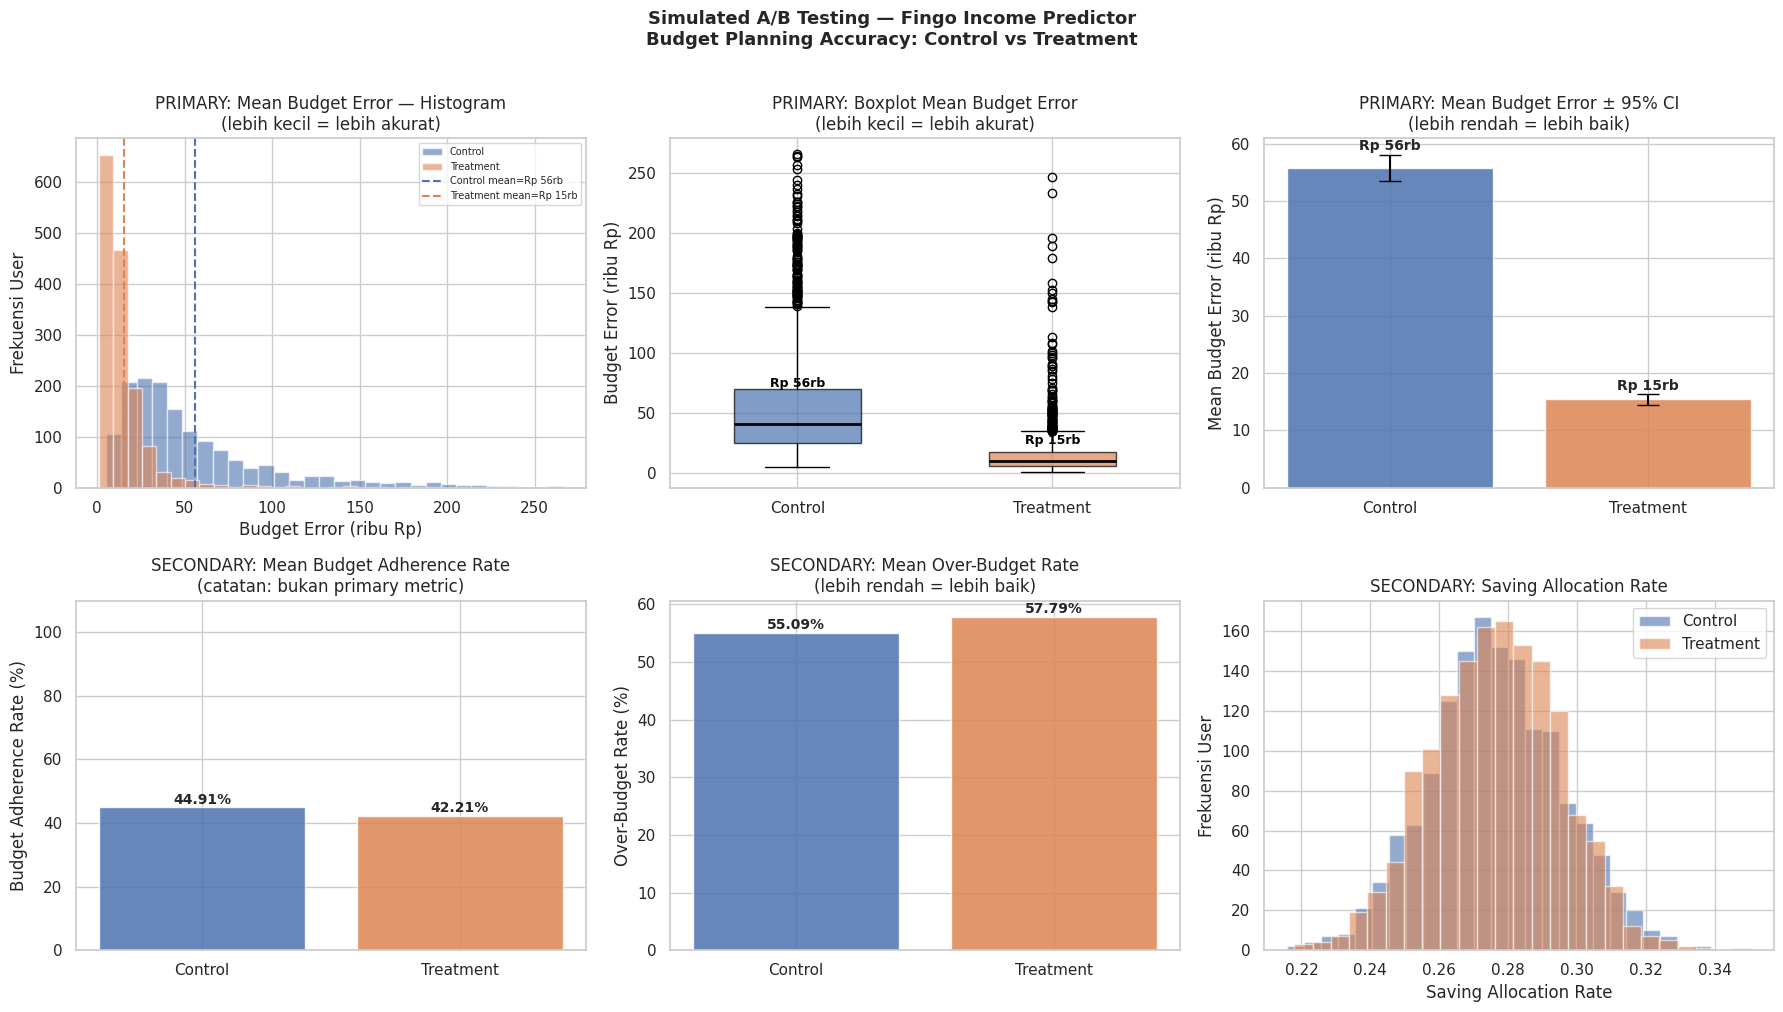

Visualisasi distribusi selesai.

Summary Primary Metric:
  Mean Budget Error Control   : Rp 56rb
  Mean Budget Error Treatment : Rp 15rb
  Difference (T - C)          : Rp -40rb (lebih kecil = Treatment lebih akurat)


In [6]:
# CELL 10.6 — Distribusi Metrik: Budget Planning Accuracy
from scipy.stats import gaussian_kde

be_c  = ctrl_users['mean_budget_error'].values
be_t  = treat_users['mean_budget_error'].values
bar_c = ctrl_users['budget_adherence_rate'].values
bar_t = treat_users['budget_adherence_rate'].values
obr_c = ctrl_users['over_budget_rate'].values
obr_t = treat_users['over_budget_rate'].values
sar_c = ctrl_users['mean_saving_allocation'].values
sar_t = treat_users['mean_saving_allocation'].values

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    'Simulated A/B Testing — Fingo Income Predictor\n'
    'Budget Planning Accuracy: Control vs Treatment',
    fontweight='bold', fontsize=13, y=1.01
)

# Panel 1: Histogram mean_budget_error (PRIMARY)
axes[0,0].hist(be_c/1e3, bins=30, alpha=0.6, label='Control',   color=COLORS['control'],   edgecolor='white')
axes[0,0].hist(be_t/1e3, bins=30, alpha=0.6, label='Treatment', color=COLORS['treatment'], edgecolor='white')
axes[0,0].axvline(be_c.mean()/1e3, color=COLORS['control'],   linestyle='--', linewidth=1.5, label=f"Control mean={fmt_idr(be_c.mean())}")
axes[0,0].axvline(be_t.mean()/1e3, color=COLORS['treatment'], linestyle='--', linewidth=1.5, label=f"Treatment mean={fmt_idr(be_t.mean())}")
axes[0,0].set_title('PRIMARY: Mean Budget Error — Histogram\n(lebih kecil = lebih akurat)')
axes[0,0].set_xlabel('Budget Error (ribu Rp)')
axes[0,0].set_ylabel('Frekuensi User')
axes[0,0].legend(fontsize=7)

# Panel 2: Boxplot mean_budget_error (PRIMARY)
bp = axes[0,1].boxplot([be_c/1e3, be_t/1e3], labels=['Control','Treatment'],
                        patch_artist=True, widths=0.5,
                        medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], [COLORS['control'], COLORS['treatment']]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[0,1].set_ylabel('Budget Error (ribu Rp)')
axes[0,1].set_title('PRIMARY: Boxplot Mean Budget Error\n(lebih kecil = lebih akurat)')
for i, (grp_arr, label) in enumerate([(be_c, 'Control'), (be_t, 'Treatment')], 1):
    axes[0,1].text(i, grp_arr.mean()/1e3 + grp_arr.std()/1e3*0.3,
                   fmt_idr(grp_arr.mean()), ha='center', va='bottom',
                   fontweight='bold', fontsize=9, color='black')

# Panel 3: Bar chart mean_budget_error + 95% CI (PRIMARY)
grp_means_be  = [be_c.mean()/1e3, be_t.mean()/1e3]
grp_errors_be = [1.96*be_c.std()/np.sqrt(n_c)/1e3, 1.96*be_t.std()/np.sqrt(n_t)/1e3]
bars3 = axes[0,2].bar(['Control', 'Treatment'], grp_means_be,
                       color=[COLORS['control'], COLORS['treatment']],
                       yerr=grp_errors_be, capsize=8,
                       edgecolor='white', alpha=0.85)
for bar, m, e in zip(bars3, grp_means_be, grp_errors_be):
    axes[0,2].text(bar.get_x()+bar.get_width()/2,
                   m+e+0.2,
                   f'Rp {m:.0f}rb', ha='center', va='bottom', fontweight='bold', fontsize=10)
axes[0,2].set_ylabel('Mean Budget Error (ribu Rp)')
axes[0,2].set_title('PRIMARY: Mean Budget Error ± 95% CI\n(lebih rendah = lebih baik)')

# Panel 4: Budget Adherence Rate (SECONDARY)
grp_bar = [bar_c.mean()*100, bar_t.mean()*100]
bars4 = axes[1,0].bar(['Control', 'Treatment'], grp_bar,
                       color=[COLORS['control'], COLORS['treatment']],
                       edgecolor='white', alpha=0.85)
for bar, v in zip(bars4, grp_bar):
    axes[1,0].text(bar.get_x()+bar.get_width()/2,
                   v+0.2, f'{v:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)
axes[1,0].set_ylabel('Budget Adherence Rate (%)')
axes[1,0].set_title('SECONDARY: Mean Budget Adherence Rate\n(catatan: bukan primary metric)')
axes[1,0].set_ylim(0, 110)

# Panel 5: Over-Budget Rate (SECONDARY)
grp_obr = [obr_c.mean()*100, obr_t.mean()*100]
bars5 = axes[1,1].bar(['Control', 'Treatment'], grp_obr,
                       color=[COLORS['control'], COLORS['treatment']],
                       edgecolor='white', alpha=0.85)
for bar, v in zip(bars5, grp_obr):
    axes[1,1].text(bar.get_x()+bar.get_width()/2,
                   v+0.2, f'{v:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)
axes[1,1].set_ylabel('Over-Budget Rate (%)')
axes[1,1].set_title('SECONDARY: Mean Over-Budget Rate\n(lebih rendah = lebih baik)')

# Panel 6: Saving Allocation Rate (SECONDARY)
axes[1,2].hist(sar_c, bins=25, alpha=0.6, label='Control',   color=COLORS['control'],   edgecolor='white')
axes[1,2].hist(sar_t, bins=25, alpha=0.6, label='Treatment', color=COLORS['treatment'], edgecolor='white')
axes[1,2].set_title('SECONDARY: Saving Allocation Rate')
axes[1,2].set_xlabel('Saving Allocation Rate')
axes[1,2].set_ylabel('Frekuensi User')
axes[1,2].legend()

plt.tight_layout()
safe_savefig('outputs/charts/ab_income_predictor_distribution.png')
plt.show()
print('Visualisasi distribusi selesai.')
print(f'\nSummary Primary Metric:')
print(f'  Mean Budget Error Control   : {fmt_idr(be_c.mean())}')
print(f'  Mean Budget Error Treatment : {fmt_idr(be_t.mean())}')
diff_be = be_t.mean() - be_c.mean()
print(f'  Difference (T - C)          : {fmt_idr(diff_be)} ({"lebih kecil = Treatment lebih akurat" if diff_be < 0 else "positif = Treatment kurang akurat"})')


## CELL 10.7 — Uji Asumsi: Normalitas & Homogenitas Variansi

1. **Shapiro-Wilk** — uji normalitas (subsampel max 500)
2. **Levene's Test** — uji homogenitas variansi

> **Decision Rule:**
> - Data normal -> Welch's t-test sebagai uji utama
> - Data tidak normal -> **Mann-Whitney U** sebagai uji utama (lebih robust)

=== Uji Asumsi — PRIMARY METRIC: mean_budget_error ===
  Hipotesis: H1: mean_budget_error_treatment < mean_budget_error_control

Shapiro-Wilk Normalitas (n=500):
  Control:   W=0.8173, p=0.000000 -> Tidak Normal
  Treatment: W=0.4756, p=0.000000 -> Tidak Normal

Levene Test Homogenitas Variansi:
  Statistic=415.8148, p=0.000000 -> Variansi Tidak Homogen

-> Kedua distribusi normal : False
-> Variansi homogen        : False
-> Uji utama               : Mann-Whitney U (one-tailed: T < C, alternative=less)
Chart disimpan: outputs/charts/ab_income_predictor_qq_plot.png


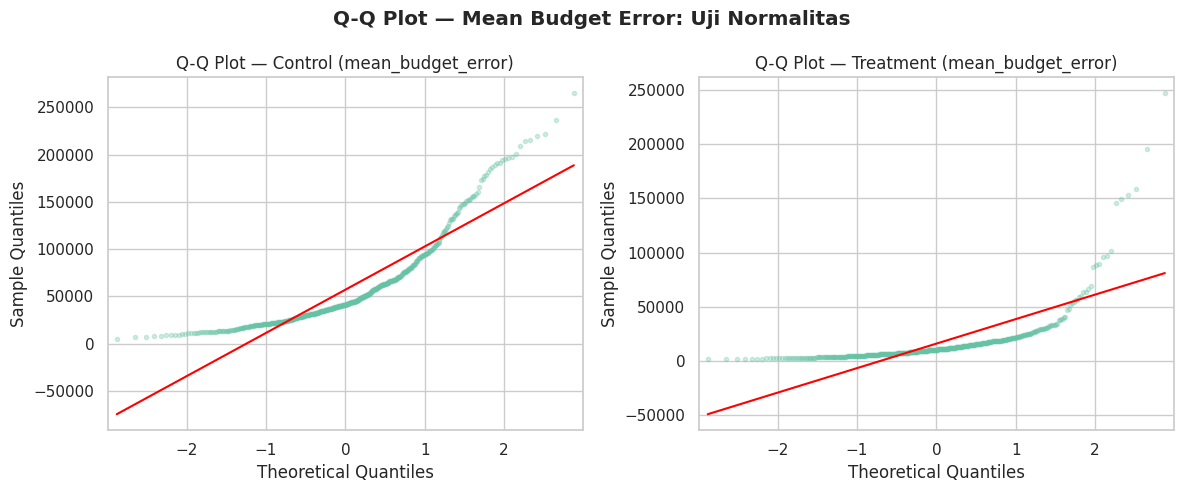

In [7]:
# CELL 10.7 — Uji Asumsi Statistik (Primary Metric: mean_budget_error)
ALPHA = 0.05
be_c = ctrl_users['mean_budget_error'].values
be_t = treat_users['mean_budget_error'].values

print('=== Uji Asumsi — PRIMARY METRIC: mean_budget_error ===')
print('  Hipotesis: H1: mean_budget_error_treatment < mean_budget_error_control')

sample_size_sw = min(500, n_c, n_t)
np.random.seed(42)
sample_c = np.random.choice(be_c, size=sample_size_sw, replace=False)
sample_t = np.random.choice(be_t, size=sample_size_sw, replace=False)

sw_c_stat, sw_c_p = shapiro(sample_c)
sw_t_stat, sw_t_p = shapiro(sample_t)
normal_c = sw_c_p > ALPHA
normal_t = sw_t_p > ALPHA

print(f'\nShapiro-Wilk Normalitas (n={sample_size_sw}):')
print(f'  Control:   W={sw_c_stat:.4f}, p={sw_c_p:.6f} -> {"Normal" if normal_c else "Tidak Normal"}')
print(f'  Treatment: W={sw_t_stat:.4f}, p={sw_t_p:.6f} -> {"Normal" if normal_t else "Tidak Normal"}')

lev_stat, lev_p = levene(be_c, be_t)
equal_var = lev_p > ALPHA

print(f'\nLevene Test Homogenitas Variansi:')
print(f'  Statistic={lev_stat:.4f}, p={lev_p:.6f} -> {"Variansi Homogen" if equal_var else "Variansi Tidak Homogen"}')

ASSUMPTION_NORMAL = normal_c and normal_t
ASSUMPTION_EQVAR  = equal_var

print(f'\n-> Kedua distribusi normal : {ASSUMPTION_NORMAL}')
print(f'-> Variansi homogen        : {ASSUMPTION_EQVAR}')
print(f'-> Uji utama               : {"Welch t-test (one-tailed: T < C)" if ASSUMPTION_NORMAL else "Mann-Whitney U (one-tailed: T < C, alternative=less)"}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Q-Q Plot — Mean Budget Error: Uji Normalitas', fontweight='bold')
sm.qqplot(sample_c, line='s', ax=axes[0], alpha=0.3, markersize=3)
axes[0].set_title('Q-Q Plot — Control (mean_budget_error)')
sm.qqplot(sample_t, line='s', ax=axes[1], alpha=0.3, markersize=3)
axes[1].set_title('Q-Q Plot — Treatment (mean_budget_error)')
plt.tight_layout()
safe_savefig('outputs/charts/ab_income_predictor_qq_plot.png')
plt.show()


## CELL 10.8 — Uji Hipotesis Utama

- **H0**: `mean_budget_error` Treatment = Control
- **H1**: `mean_budget_error` Treatment < Control (one-tailed, alpha=0.05)

> Karena nilai lebih kecil = lebih baik, uji dilakukan dengan `alternative='less'`
> (Treatment diharapkan memiliki budget error yang lebih rendah).

Uji yang dijalankan:
1. Mann-Whitney U Test (uji utama jika data tidak normal, alternative='less')
2. Welch's t-test (uji pendukung / utama jika normal, one-tailed T < C)
3. Cohen's d — effect size
4. 95% Confidence Interval
5. Bootstrap CI


In [8]:
# CELL 10.8 — Uji Hipotesis Utama + Effect Size
from scipy.stats import t as t_dist

be_c = ctrl_users['mean_budget_error'].values
be_t = treat_users['mean_budget_error'].values

mean_control   = be_c.mean()
mean_treatment = be_t.mean()
absolute_diff  = mean_treatment - mean_control   # negatif = Treatment lebih baik
relative_reduction = (absolute_diff / mean_control * 100) if mean_control > 0 else 0
# Untuk budget error: negative diff = positive result for Treatment
treatment_better = absolute_diff < 0

print('=== Uji Hipotesis Utama ===')
print(f'H0: mean_budget_error_treatment = mean_budget_error_control')
print(f'H1: mean_budget_error_treatment < mean_budget_error_control (one-tailed)')
print(f'Significance level alpha = {ALPHA}')
print(f'  (Untuk budget_error: lebih kecil = lebih baik)')

# 1. Mann-Whitney U (one-tailed, alternative='less': Treatment < Control)
# mannwhitneyu(treatment, control, alternative='less') menguji H1: T < C
mw_stat, mw_p = mannwhitneyu(be_t, be_c, alternative='less')
mw_reject = mw_p < ALPHA

role_mw = '[UTAMA]' if not ASSUMPTION_NORMAL else '[PENDUKUNG]'
print(f'\n1. {role_mw} Mann-Whitney U Test (one-tailed: T < C, alternative=less):')
print(f'   U-statistic = {mw_stat:.0f}')
print(f'   p-value     = {mw_p:.6f}')
print(f'   Keputusan   : {"Tolak H0 — Treatment memiliki budget error lebih rendah" if mw_reject else "Gagal Tolak H0"}')

# 2. Welch t-test (one-tailed, H1: T < C)
# ttest_ind(be_t, be_c) → positif jika mean_t > mean_c, negatif jika mean_t < mean_c
# H1: T < C → kita harapkan t_stat < 0, p one-tailed = t_p_two/2 jika t_stat < 0
t_stat, t_p_two = ttest_ind(be_t, be_c, equal_var=False)
# One-tailed p untuk H1: T < C
t_p_one = t_p_two / 2 if t_stat < 0 else 1 - t_p_two / 2
t_reject = t_p_one < ALPHA

role_t = '[UTAMA]' if ASSUMPTION_NORMAL else '[PENDUKUNG]'
print(f'\n2. {role_t} Welch t-test (one-tailed: T < C):')
print(f'   t-statistic         = {t_stat:.4f}')
print(f'   p-value (one-tailed)= {t_p_one:.6f}')
print(f'   Keputusan           : {"Tolak H0 — Treatment memiliki budget error lebih rendah" if t_reject else "Gagal Tolak H0"}')
if not ASSUMPTION_NORMAL:
    print(f'   Catatan: data tidak normal → t-test bukan dasar keputusan utama.')

# 3. Cohen's d
pooled_std = np.sqrt((be_c.std()**2 + be_t.std()**2) / 2)
cohens_d   = (mean_treatment - mean_control) / pooled_std if pooled_std > 0 else 0
# Untuk budget_error: d negatif = Treatment lebih baik
effect_label = 'Kecil' if abs(cohens_d) < 0.2 else ('Sedang' if abs(cohens_d) < 0.8 else 'Besar')
direction_label = 'Treatment lebih baik (budget error lebih rendah)' if cohens_d < 0 else 'Treatment lebih buruk'

print(f"\n3. Effect Size (Cohen's d):")
print(f"   Cohen's d = {cohens_d:.4f} -> Efek {effect_label}")
print(f"   Interpretasi: {direction_label}")
print(f"   (|d| < 0.2 = kecil, 0.2-0.8 = sedang, > 0.8 = besar)")

# 4. Lift / Reduction Analysis
print(f'\n4. Budget Error Reduction Analysis (less_is_better):')
print(f'   Mean Budget Error Control   : {fmt_idr(mean_control)}')
print(f'   Mean Budget Error Treatment : {fmt_idr(mean_treatment)}')
print(f'   Absolute Diff (T - C)       : {fmt_idr(absolute_diff)} ({"+lebih buruk" if absolute_diff > 0 else "lebih baik untuk Treatment"})')
print(f'   Relative Change             : {relative_reduction:+.2f}%  (negatif = penurunan error = Treatment lebih akurat)')

# 5. 95% CI (Welch) untuk selisih mean (T - C)
se_diff  = np.sqrt(be_t.var()/n_t + be_c.var()/n_c)
df_welch = (be_t.var()/n_t + be_c.var()/n_c)**2 /            ((be_t.var()/n_t)**2/(n_t-1) + (be_c.var()/n_c)**2/(n_c-1))
t_crit   = t_dist.ppf(0.975, df=df_welch)
ci_low   = absolute_diff - t_crit * se_diff
ci_high  = absolute_diff + t_crit * se_diff

# FIX: CI crossing zero logic yang benar
ci_cross_zero = ci_low <= 0 <= ci_high

# Interpretasi CI untuk budget_error (less_is_better)
if ci_high < 0:
    ci_interp = 'Seluruh CI negatif → Treatment secara statistik memiliki budget error lebih rendah.'
elif ci_low > 0:
    ci_interp = 'Seluruh CI positif → Treatment secara statistik memiliki budget error lebih tinggi.'
else:
    ci_interp = 'CI melewati nol → perbedaan belum konklusif.'

print(f'\n5. 95% CI untuk selisih mean Budget Error (T - C):')
print(f'   [{fmt_idr(ci_low)}, {fmt_idr(ci_high)}]')
print(f'   CI melewati nol : {ci_cross_zero}')
print(f'   Interpretasi    : {ci_interp}')

# 6. Bootstrap CI
np.random.seed(42)
n_boot = 2000
boot_diffs = np.array([
    np.random.choice(be_t, n_t, True).mean() - np.random.choice(be_c, n_c, True).mean()
    for _ in range(n_boot)
])
ci_boot_low  = np.percentile(boot_diffs, 2.5)
ci_boot_high = np.percentile(boot_diffs, 97.5)

ci_boot_cross_zero = ci_boot_low <= 0 <= ci_boot_high
if ci_boot_high < 0:
    ci_boot_interp = 'CI bootstrap seluruhnya negatif → Treatment lebih akurat (konsisten).'
elif ci_boot_low > 0:
    ci_boot_interp = 'CI bootstrap seluruhnya positif → Treatment kurang akurat.'
else:
    ci_boot_interp = 'CI bootstrap melewati nol → perbedaan belum konklusif.'

print(f'\n6. Bootstrap 95% CI (n={n_boot}): [{fmt_idr(ci_boot_low)}, {fmt_idr(ci_boot_high)}]')
print(f'   {ci_boot_interp}')

# Final Decision
FINAL_DECISION = t_reject if ASSUMPTION_NORMAL else mw_reject
primary_test   = 'Welch t-test' if ASSUMPTION_NORMAL else 'Mann-Whitney U'
primary_p      = t_p_one        if ASSUMPTION_NORMAL else mw_p

print(f'\n=== KEPUTUSAN AKHIR ({primary_test} sebagai Uji Utama) ===')
if FINAL_DECISION:
    print('Tolak H0: Terdapat bukti statistik bahwa Treatment (Income Predictor + Budget Adaptif)')
    print('         menghasilkan mean_budget_error yang lebih rendah dibandingkan Control (budget manual).')
    print('         Ini menunjukkan Income Predictor membantu membuat perencanaan budget yang')
    print('         lebih akurat terhadap kondisi income aktual user.')
else:
    print('Gagal Tolak H0: Belum terdapat bukti statistik yang cukup bahwa Treatment')
    print(f'memiliki budget error yang lebih rendah secara signifikan dari Control.')
    print(f'Arah efek: {"Treatment lebih baik (budget error lebih rendah)" if treatment_better else "Treatment kurang baik"}')
    print(f'Namun belum konklusif pada alpha={ALPHA}.')

print(f'\nCatatan: Keputusan di atas hanya berlaku untuk primary metric (mean_budget_error).')
print(f'Budget adherence rate adalah secondary metric dan dianalisis terpisah.')


=== Uji Hipotesis Utama ===
H0: mean_budget_error_treatment = mean_budget_error_control
H1: mean_budget_error_treatment < mean_budget_error_control (one-tailed)
Significance level alpha = 0.05
  (Untuk budget_error: lebih kecil = lebih baik)

1. [UTAMA] Mann-Whitney U Test (one-tailed: T < C, alternative=less):
   U-statistic = 229456
   p-value     = 0.000000
   Keputusan   : Tolak H0 — Treatment memiliki budget error lebih rendah

2. [PENDUKUNG] Welch t-test (one-tailed: T < C):
   t-statistic         = -31.6231
   p-value (one-tailed)= 0.000000
   Keputusan           : Tolak H0 — Treatment memiliki budget error lebih rendah
   Catatan: data tidak normal → t-test bukan dasar keputusan utama.

3. Effect Size (Cohen's d):
   Cohen's d = -1.1546 -> Efek Besar
   Interpretasi: Treatment lebih baik (budget error lebih rendah)
   (|d| < 0.2 = kecil, 0.2-0.8 = sedang, > 0.8 = besar)

4. Budget Error Reduction Analysis (less_is_better):
   Mean Budget Error Control   : Rp 56rb
   Mean Budget

## CELL 10.9 — Analisis Secondary Metrics

In [9]:
# CELL 10.9 — Analisis Secondary Metrics
print('=== Secondary Metrics Analysis ===')
print('  (budget_adherence_rate, over_budget_rate, expense_to_income_ratio,')
print('   saving_allocation_rate, budget_gap)\n')

secondary_metrics = [
    ('budget_adherence_rate',    'Budget Adherence Rate',      'greater'),
    ('over_budget_rate',         'Over-Budget Rate',           'less'),
    ('mean_expense_to_income',   'Expense-to-Income Ratio',    'less'),
    ('mean_saving_allocation',   'Saving Allocation Rate',     'greater'),
    ('budget_gap',               'Budget Gap (planned-ideal)', 'two-sided'),
]

secondary_rows = []
for col, label, alt in secondary_metrics:
    if col not in df_user.columns:
        continue
    c_vals = ctrl_users[col].dropna().values
    t_vals = treat_users[col].dropna().values
    if len(c_vals) < 5 or len(t_vals) < 5:
        continue
    u_stat, u_p = mannwhitneyu(t_vals, c_vals, alternative=alt)
    diff = t_vals.mean() - c_vals.mean()
    # Interpret direction correctly
    if alt == 'less':
        direction = 'Treatment lebih baik' if diff < 0 else 'Treatment lebih buruk'
    elif alt == 'greater':
        direction = 'Treatment lebih baik' if diff > 0 else 'Treatment lebih buruk'
    else:
        direction = 'Dua arah'
    secondary_rows.append({
        'Metrik': label,
        'Mean Control': f'{c_vals.mean():.4f}',
        'Mean Treatment': f'{t_vals.mean():.4f}',
        'Diff (T-C)': f'{diff:+.4f}',
        'MW p-value': f'{u_p:.4f}',
        'Sig': 'Ya' if u_p < 0.05 else '-',
        'Arah': direction,
    })
    print(f'{label}:')
    print(f'  Control={c_vals.mean():.4f} | Treatment={t_vals.mean():.4f} | Diff={diff:+.4f}')
    print(f'  p={u_p:.4f} -> {"Signifikan" if u_p < 0.05 else "Tidak signifikan"} | {direction}')

print()
df_secondary = pd.DataFrame(secondary_rows)
if not df_secondary.empty:
    print(df_secondary.to_string(index=False))

print()
print('=== Interpretasi Secondary Metrics ===')
bar_c_sm = ctrl_users['budget_adherence_rate'].values
bar_t_sm = treat_users['budget_adherence_rate'].values
bar_diff  = bar_t_sm.mean() - bar_c_sm.mean()
print(f'Budget Adherence Rate:')
print(f'  Control={bar_c_sm.mean():.2%} | Treatment={bar_t_sm.mean():.2%} | Diff={bar_diff*100:+.2f}pp')
if bar_diff < 0:
    print('  Catatan: Treatment memiliki budget adherence lebih rendah dari Control.')
    print('  Ini BUKAN indikasi kegagalan Income Predictor, karena:')
    print('  Income Predictor berfungsi memperbaiki AKURASI perencanaan budget (mean_budget_error),')
    print('  bukan secara langsung mengubah perilaku pengeluaran user.')
    print('  Budget adherence dipengaruhi oleh kepatuhan user terhadap rekomendasi,')
    print('  yang memerlukan validasi terpisah melalui eksperimen live.')
else:
    print('  Budget adherence Treatment >= Control. Secondary metric ini mendukung hasil positif.')


=== Secondary Metrics Analysis ===
  (budget_adherence_rate, over_budget_rate, expense_to_income_ratio,
   saving_allocation_rate, budget_gap)

Budget Adherence Rate:
  Control=0.4491 | Treatment=0.4221 | Diff=-0.0270
  p=1.0000 -> Tidak signifikan | Treatment lebih buruk
Over-Budget Rate:
  Control=0.5509 | Treatment=0.5779 | Diff=+0.0270
  p=1.0000 -> Tidak signifikan | Treatment lebih buruk
Expense-to-Income Ratio:
  Control=0.7249 | Treatment=0.7247 | Diff=-0.0002
  p=0.2893 -> Tidak signifikan | Treatment lebih baik
Saving Allocation Rate:
  Control=0.2764 | Treatment=0.2765 | Diff=+0.0001
  p=0.3057 -> Tidak signifikan | Treatment lebih baik
Budget Gap (planned-ideal):
  Control=-3104.6558 | Treatment=2196.1017 | Diff=+5300.7575
  p=0.0000 -> Signifikan | Dua arah

                    Metrik Mean Control Mean Treatment Diff (T-C) MW p-value Sig                  Arah
     Budget Adherence Rate       0.4491         0.4221    -0.0270     1.0000   - Treatment lebih buruk
          Ov

## CELL 10.10 — Subgroup Analysis per Gig Type

> ⚠️ **Disclaimer:** Hasil subgroup bersifat **eksploratorif** dan tidak menggantikan analisis
> utama. Diperlukan eksperimen dedicated per segmen sebelum menarik kesimpulan kausal.

=== Subgroup Analysis per Gig Type (Eksploratorif) ===
[Bukan klaim utama - perlu validasi lanjutan]

        Gig Type  n_ctrl  n_treat BE Control BE Treatment Diff (T-C) Rel Reduction   MW p Indikasi Cohen'd
 content_creator     139      138    Rp 54rb      Rp 13rb   Rp -41rb        -76.7% 0.0000  positif  -1.289
freelance_desain     230      229    Rp 81rb      Rp 21rb   Rp -59rb        -73.4% 0.0000  positif  -1.330
    freelance_it     180      180   Rp 108rb      Rp 28rb   Rp -80rb        -74.4% 0.0000  positif  -1.543
   jualan_online     248      248    Rp 36rb      Rp 10rb   Rp -26rb        -72.1% 0.0000  positif  -1.609
           kurir     113      112    Rp 36rb      Rp 11rb   Rp -25rb        -68.3% 0.0000  positif  -2.910
     ojek_online     115      114    Rp 37rb      Rp 11rb   Rp -26rb        -69.2% 0.0000  positif  -2.130
  pekerja_harian     249      249    Rp 44rb      Rp 13rb   Rp -31rb        -70.3% 0.0000  positif  -1.616
           tutor     228      228    Rp 45

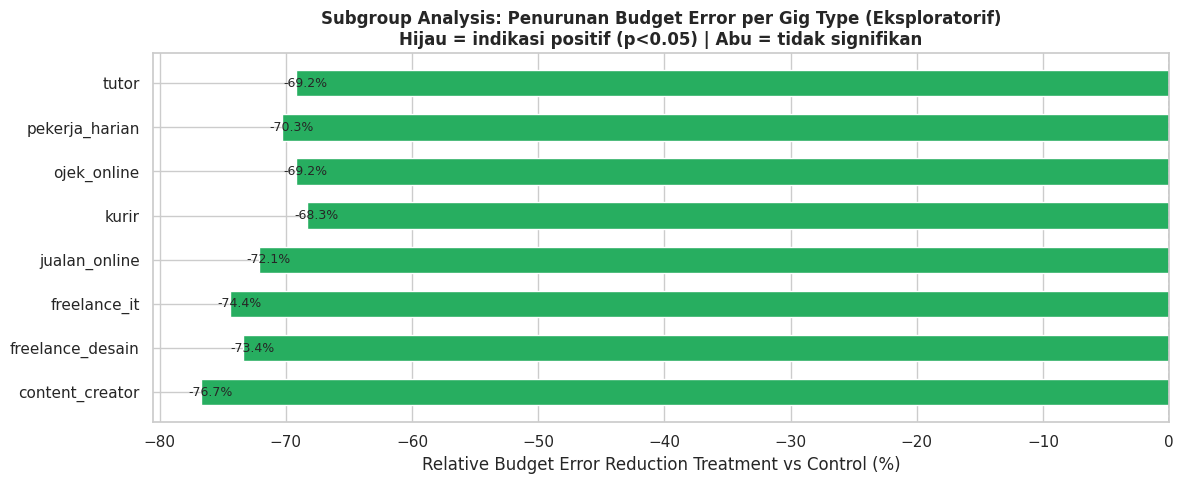

In [10]:
# CELL 10.10 — Subgroup Analysis per Gig Type (Primary: mean_budget_error)
print('=== Subgroup Analysis per Gig Type (Eksploratorif) ===')
print('[Bukan klaim utama - perlu validasi lanjutan]\n')

subgroup_results = []
for gt in sorted(df_user['gig_type'].unique()):
    sub   = df_user[df_user['gig_type'] == gt]
    c_sub = sub[sub['group'] == 'control']['mean_budget_error'].values
    t_sub = sub[sub['group'] == 'treatment']['mean_budget_error'].values
    if len(c_sub) < 5 or len(t_sub) < 5:
        continue
    # alternative='less': H1 = treatment budget error < control budget error
    u_stat, u_p = mannwhitneyu(t_sub, c_sub, alternative='less')
    diff_abs = t_sub.mean() - c_sub.mean()
    rel_red  = (diff_abs / c_sub.mean() * 100) if c_sub.mean() > 0 else 0
    d_sub    = diff_abs / np.sqrt((c_sub.std()**2+t_sub.std()**2)/2) if c_sub.std()+t_sub.std()>0 else 0
    subgroup_results.append({
        'Gig Type'        : gt,
        'n_ctrl'          : len(c_sub),
        'n_treat'         : len(t_sub),
        'BE Control'      : fmt_idr(c_sub.mean()),
        'BE Treatment'    : fmt_idr(t_sub.mean()),
        'Diff (T-C)'      : fmt_idr(diff_abs),
        'Rel Reduction'   : f'{rel_red:+.1f}%',
        'MW p'            : f'{u_p:.4f}',
        'Indikasi'        : 'positif' if u_p < 0.05 else '-',
        "Cohen'd"         : f'{d_sub:.3f}',
    })

if subgroup_results:
    df_subgroup = pd.DataFrame(subgroup_results)
    print(df_subgroup.to_string(index=False))
    print()
    sig_subs = [r['Gig Type'] for r in subgroup_results if r['Indikasi'] == 'positif']
    if sig_subs:
        print(f'Segmen dengan indikasi budget error lebih rendah: {", ".join(sig_subs)}')
    else:
        print('Tidak ada segmen yang signifikan pada alpha=0.05.')

# Chart: Relative reduction per gig type
rel_vals   = [float(r['Rel Reduction'].replace('%','').replace('+','')) for r in subgroup_results]
gig_labels = [r['Gig Type'] for r in subgroup_results]
ind_colors = ['#27ae60' if r['Indikasi'] == 'positif' else '#bdc3c7' for r in subgroup_results]

fig, ax = plt.subplots(figsize=(12, 5))
if rel_vals:
    bars_sg = ax.barh(gig_labels, rel_vals, color=ind_colors, edgecolor='white', height=0.6)
    ax.axvline(0, color='black', linewidth=1, linestyle='--')
    for bar, val in zip(bars_sg, rel_vals):
        offset = 0.3 if val >= 0 else -1.0
        ax.text(bar.get_width()+offset, bar.get_y()+bar.get_height()/2,
                f'{val:+.1f}%', va='center', fontsize=9)
ax.set_xlabel('Relative Budget Error Reduction Treatment vs Control (%)')
ax.set_title(
    'Subgroup Analysis: Penurunan Budget Error per Gig Type (Eksploratorif)\n'
    'Hijau = indikasi positif (p<0.05) | Abu = tidak signifikan',
    fontweight='bold'
)
plt.tight_layout()
safe_savefig('outputs/charts/ab_income_predictor_subgroup.png')
plt.show()


## CELL 10.11 — Power Analysis & Sample Size Calculation

=== Power Analysis (berdasarkan effect size mean_budget_error) ===

Effect size (Cohen's d) dari mean_budget_error: -1.1546 (|d|=1.1546)
Interpretasi: Treatment lebih baik (budget error lebih rendah)

Sample size yang dibutuhkan per grup (alpha=0.05, power=0.8):
  d=0.100 -> n=1,238 per grup 
  d=0.200 -> n=310 per grup 
  d=0.300 -> n=139 per grup 
  d=0.500 -> n=51 per grup 
  d=1.155 -> n=11 per grup <- Aktual (eksperimen ini)

Power yang dicapai dengan n=1498: 1.0000 (Cukup)
Chart disimpan: outputs/charts/ab_income_predictor_power_analysis.png


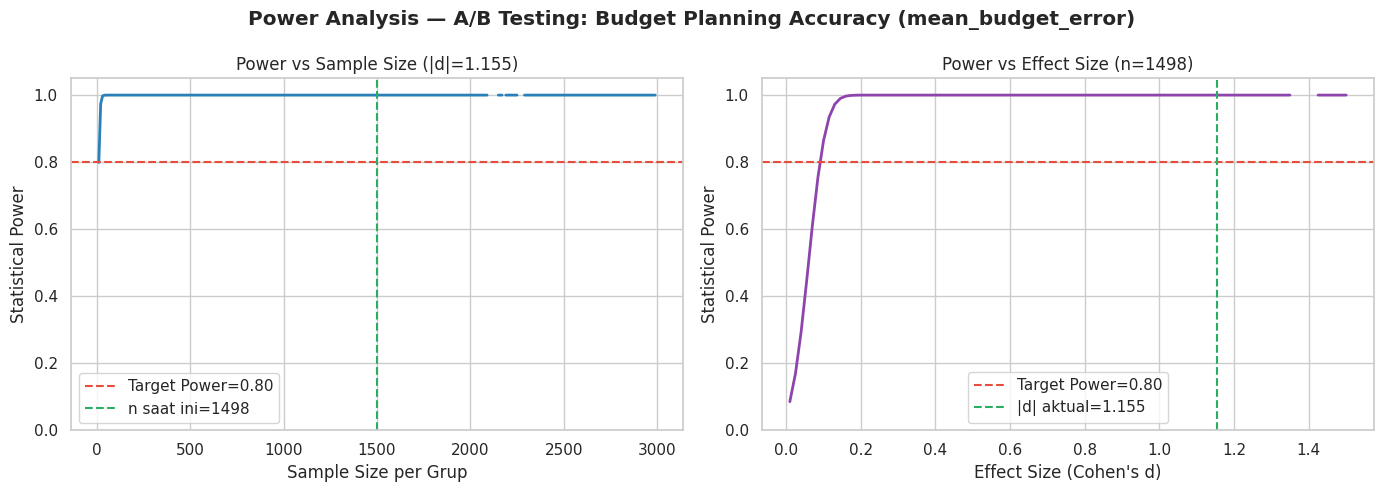

In [11]:
# CELL 10.11 — Power Analysis (Primary Metric: mean_budget_error)
from statsmodels.stats.power import TTestIndPower

print('=== Power Analysis (berdasarkan effect size mean_budget_error) ===')
ALPHA_POWER  = 0.05
POWER_TARGET = 0.80
EFFECT_SIZES = [0.1, 0.2, 0.3, 0.5, abs(cohens_d)]

analysis = TTestIndPower()
n_current = min(n_c, n_t)

print(f"\nEffect size (Cohen's d) dari mean_budget_error: {cohens_d:.4f} (|d|={abs(cohens_d):.4f})")
print(f'Interpretasi: {"Treatment lebih baik (budget error lebih rendah)" if cohens_d < 0 else "Treatment lebih buruk"}')
print(f'\nSample size yang dibutuhkan per grup (alpha={ALPHA_POWER}, power={POWER_TARGET}):')
for es in EFFECT_SIZES:
    n_req = analysis.solve_power(effect_size=max(es, 0.001), alpha=ALPHA_POWER,
                                  power=POWER_TARGET, alternative='larger')
    label = '<- Aktual (eksperimen ini)' if es == abs(cohens_d) else ''
    print(f'  d={es:.3f} -> n={int(np.ceil(n_req)):,} per grup {label}')

power_achieved = analysis.solve_power(
    effect_size=max(abs(cohens_d), 0.001), nobs1=n_current,
    alpha=ALPHA_POWER, alternative='larger'
)
print(f'\nPower yang dicapai dengan n={n_current}: {power_achieved:.4f} '
      f'({"Cukup" if power_achieved >= POWER_TARGET else "Kurang - perlu lebih banyak data"})')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Power Analysis — A/B Testing: Budget Planning Accuracy (mean_budget_error)", fontweight='bold')

ns     = np.arange(10, max(300, n_current*2), 10)
powers = [analysis.solve_power(effect_size=max(abs(cohens_d), 0.001), nobs1=n,
                                alpha=ALPHA_POWER, alternative='larger') for n in ns]
axes[0].plot(ns, powers, color='#2980b9', linewidth=2)
axes[0].axhline(0.80, color='#e74c3c', linestyle='--', label='Target Power=0.80')
axes[0].axvline(n_current, color='#27ae60', linestyle='--', label=f'n saat ini={n_current}')
axes[0].set_xlabel('Sample Size per Grup')
axes[0].set_ylabel('Statistical Power')
axes[0].set_title(f"Power vs Sample Size (|d|={abs(cohens_d):.3f})")
axes[0].legend(); axes[0].set_ylim(0, 1.05)

es_range  = np.linspace(0.01, 1.5, 100)
pow_range = [analysis.solve_power(effect_size=es, nobs1=n_current, alpha=ALPHA_POWER,
                                   alternative='larger') for es in es_range]
axes[1].plot(es_range, pow_range, color='#8e44ad', linewidth=2)
axes[1].axhline(0.80, color='#e74c3c', linestyle='--', label='Target Power=0.80')
axes[1].axvline(abs(cohens_d), color='#27ae60', linestyle='--', label=f"|d| aktual={abs(cohens_d):.3f}")
axes[1].set_xlabel("Effect Size (Cohen's d)")
axes[1].set_ylabel('Statistical Power')
axes[1].set_title(f'Power vs Effect Size (n={n_current})')
axes[1].legend(); axes[1].set_ylim(0, 1.05)

plt.tight_layout()
safe_savefig('outputs/charts/ab_income_predictor_power_analysis.png')
plt.show()


## CELL 10.12 — Visualisasi Ringkasan A/B Test

Chart disimpan: outputs/charts/ab_income_predictor_summary.png


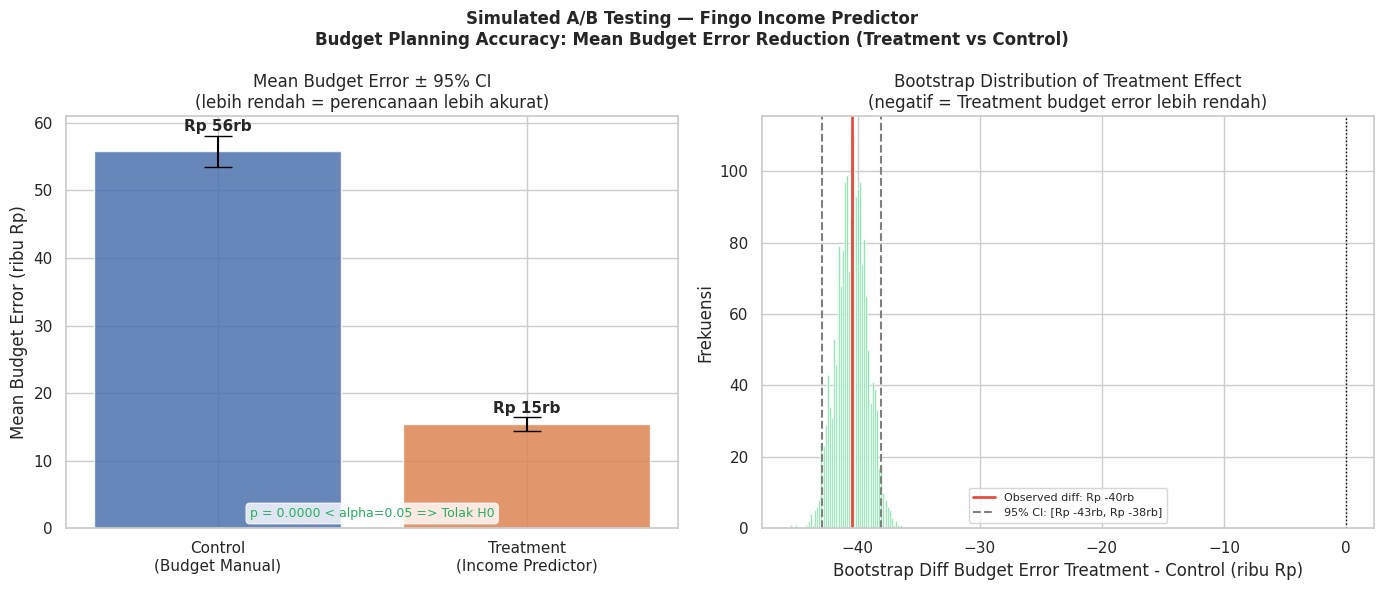

Primary Metric Summary:
  Mean Budget Error Control   : Rp 56rb
  Mean Budget Error Treatment : Rp 15rb
  Absolute Diff (T-C)         : Rp -40rb
  Relative Change             : -72.43% (negatif = Treatment lebih akurat)
  Mann-Whitney U p-value      : 0.000000
  Keputusan                   : Tolak H0 - Treatment budget error lebih rendah


In [12]:
# CELL 10.12 — Summary Visualization (Primary Metric: mean_budget_error)
be_c = ctrl_users['mean_budget_error'].values
be_t = treat_users['mean_budget_error'].values

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    'Simulated A/B Testing — Fingo Income Predictor\n'
    'Budget Planning Accuracy: Mean Budget Error Reduction (Treatment vs Control)',
    fontweight='bold', fontsize=12
)

# Panel 1: Bar mean_budget_error +/- CI
grp_labels = ['Control\n(Budget Manual)', 'Treatment\n(Income Predictor)']
grp_means_be  = [be_c.mean()/1e3, be_t.mean()/1e3]
grp_errors_be = [1.96*be_c.std()/np.sqrt(n_c)/1e3, 1.96*be_t.std()/np.sqrt(n_t)/1e3]
bars_s = axes[0].bar(grp_labels, grp_means_be,
                      color=[COLORS['control'], COLORS['treatment']],
                      yerr=grp_errors_be, capsize=10, edgecolor='white', alpha=0.85)
for bar, m, e in zip(bars_s, grp_means_be, grp_errors_be):
    axes[0].text(bar.get_x()+bar.get_width()/2, m+e+0.2,
                 f'Rp {m:.0f}rb', ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[0].set_ylabel('Mean Budget Error (ribu Rp)')
axes[0].set_title('Mean Budget Error ± 95% CI\n(lebih rendah = perencanaan lebih akurat)')
decision_txt = f'p = {primary_p:.4f} {"< alpha=0.05 => Tolak H0" if FINAL_DECISION else ">= alpha=0.05 => Gagal Tolak H0"}'
axes[0].text(0.5, 0.02, decision_txt, ha='center', va='bottom',
             transform=axes[0].transAxes, fontsize=9,
             color='#27ae60' if FINAL_DECISION else '#e74c3c',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Panel 2: Bootstrap distribution (mean_budget_error diff T - C)
boot_be_diffs = np.array([
    np.random.choice(be_t, n_t, True).mean() - np.random.choice(be_c, n_c, True).mean()
    for _ in range(2000)
])
ci_boot_be_low  = np.percentile(boot_be_diffs, 2.5)
ci_boot_be_high = np.percentile(boot_be_diffs, 97.5)

axes[1].hist(boot_be_diffs/1e3, bins=60, color='#2ecc71', edgecolor='white', alpha=0.7)
axes[1].axvline(absolute_diff/1e3, color='#e74c3c', linewidth=2,
                label=f'Observed diff: {fmt_idr(absolute_diff)}')
axes[1].axvline(ci_boot_be_low/1e3, color='gray', linewidth=1.5, linestyle='--',
                label=f'95% CI: [{fmt_idr(ci_boot_be_low)}, {fmt_idr(ci_boot_be_high)}]')
axes[1].axvline(ci_boot_be_high/1e3, color='gray', linewidth=1.5, linestyle='--')
axes[1].axvline(0, color='black', linewidth=1, linestyle=':')
axes[1].set_xlabel('Bootstrap Diff Budget Error Treatment - Control (ribu Rp)')
axes[1].set_ylabel('Frekuensi')
axes[1].set_title('Bootstrap Distribution of Treatment Effect\n(negatif = Treatment budget error lebih rendah)')
axes[1].legend(fontsize=8)

plt.tight_layout()
safe_savefig('outputs/charts/ab_income_predictor_summary.png')
plt.show()

print(f'Primary Metric Summary:')
print(f'  Mean Budget Error Control   : {fmt_idr(be_c.mean())}')
print(f'  Mean Budget Error Treatment : {fmt_idr(be_t.mean())}')
print(f'  Absolute Diff (T-C)         : {fmt_idr(absolute_diff)}')
print(f'  Relative Change             : {relative_reduction:+.2f}% (negatif = Treatment lebih akurat)')
print(f'  {primary_test} p-value      : {primary_p:.6f}')
print(f'  Keputusan                   : {"Tolak H0 - Treatment budget error lebih rendah" if FINAL_DECISION else "Gagal Tolak H0"}')


## CELL 10.13 — Generate Laporan A/B Testing Markdown

In [13]:
# CELL 10.13 — Generate Laporan Markdown (Primary: mean_budget_error)
ensure_dir('outputs/reports/')

if FINAL_DECISION:
    conclusion_body = (
        'Simulasi A/B Testing menunjukkan bahwa penggunaan Income Predictor sebagai dasar '
        'Budget Planner adaptif dapat menurunkan budget error dibandingkan budgeting manual. '
        'Hal ini menunjukkan bahwa Income Predictor membantu menghasilkan rencana budget yang '
        'lebih akurat terhadap kondisi income aktual. '
        f'Uji {primary_test} menghasilkan p-value = {primary_p:.6f} (< alpha={ALPHA}), '
        f'sehingga H0 ditolak. Relative reduction budget error sebesar {relative_reduction:+.2f}% '
        f"mengindikasikan efek yang bermakna (Cohen's d = {cohens_d:.4f}, {effect_label}).\n\n"
        'Namun, peningkatan akurasi budget belum otomatis menurunkan over-budget rate atau '
        'meningkatkan budget adherence, karena perilaku pengeluaran pengguna tetap dipengaruhi '
        'oleh kepatuhan terhadap rekomendasi. Dampak terhadap budget adherence dan over-budget '
        'rate perlu divalidasi lebih lanjut melalui eksperimen live.\n\n'
        'Karena data yang digunakan bersifat synthetic, hasil ini harus dipahami sebagai '
        'proof-of-concept dan masih memerlukan validasi dengan eksperimen live pada pengguna nyata.'
    )
else:
    conclusion_body = (
        f'Treatment menunjukkan arah penurunan budget error '
        f'(relative change {relative_reduction:+.2f}%), '
        f'tetapi belum terdapat bukti statistik yang cukup untuk menyatakan bahwa penggunaan '
        f'Income Predictor secara signifikan lebih baik dibandingkan budgeting manual '
        f'({primary_test} p={primary_p:.6f} >= alpha={ALPHA}).\n\n'
        'Validasi lanjutan diperlukan dengan data yang lebih besar, metrik perilaku yang lebih '
        'lengkap, dan eksperimen live pada pengguna nyata.'
    )

be_c_vals = ctrl_users['mean_budget_error'].values
be_t_vals = treat_users['mean_budget_error'].values
bar_c_vals = ctrl_users['budget_adherence_rate'].values
bar_t_vals = treat_users['budget_adherence_rate'].values

report_lines = [
    '# Laporan A/B Testing — Fingo Income Predictor',
    '**Simulated A/B Testing: Impact of Income Prediction on Budget Planning Accuracy**',
    '**Tim CC26-PSU217** | Notebook 10',
    '',
    '---',
    '',
    '## Disclaimer',
    '> Notebook ini menggunakan **synthetic dataset** untuk mensimulasikan pipeline evaluasi fitur',
    '> **Income Predictor** yang mendukung **Budget Planner adaptif** Fingo.',
    '> Seluruh hasil harus diinterpretasikan sebagai **proof-of-concept**, bukan sebagai bukti',
    '> kausalitas atau efektivitas fitur di dunia nyata.',
    '> Validasi live experiment pada pengguna nyata tetap diperlukan.',
    '',
    '---',
    '',
    '## 1. Latar Belakang',
    'Fingo Income Predictor menggunakan data synthetic income time-series 52 minggu untuk',
    'memprediksi pendapatan pengguna gig worker. Output prediksi income digunakan untuk',
    'membantu pengguna menyusun budget yang lebih realistis melalui **Budget Planner adaptif**.',
    '',
    'A/B Testing ini dirancang untuk menguji apakah pengguna yang mendapatkan bantuan prediksi',
    'income menghasilkan perencanaan anggaran yang **lebih akurat** dibandingkan pengguna yang',
    'membuat budget manual berdasarkan rata-rata income historis.',
    '',
    '> **Catatan penting**: Income Predictor tidak diuji untuk menaikkan pendapatan dan tidak',
    '> langsung menjamin user tidak over-budget. Income Predictor diuji sebagai alat bantu',
    '> budget planning. Dampak terhadap perilaku pengeluaran (budget adherence, over-budget rate)',
    '> perlu divalidasi terpisah melalui eksperimen live.',
    '',
    '## 2. Desain Eksperimen',
    '',
    '| Elemen | Deskripsi |',
    '|--------|-----------|',
    f'| Sumber data | synthetic_52week_user_income.csv ({N_TOTAL:,} user, 52 minggu) |',
    '| Metode assignment | Stratified random 50:50 per gig_type |',
    '| Control Group | Budget manual berdasarkan rolling mean 4 minggu income historis |',
    '| Treatment Group | Budget adaptif berdasarkan predicted income (Income Predictor) |',
    f'| N Control | {n_c:,} user |',
    f'| N Treatment | {n_t:,} user |',
    f'| **Primary Metric** | `mean_budget_error` — rata-rata selisih absolut antara planned budget dan ideal budget (actual_income × BUDGET_RATIO) |',
    f'| Secondary Metrics | `budget_adherence_rate`, `over_budget_rate`, `expense_to_income_ratio`, `saving_allocation_rate`, `budget_gap` |',
    '',
    '## 3. Hipotesis',
    '',
    '- **H0**: mean_budget_error Treatment = Control',
    '- **H1**: mean_budget_error Treatment < Control (one-tailed)',
    f'- Significance level: alpha = {ALPHA}',
    '- Interpretasi: nilai lebih kecil = budget planning lebih akurat',
    '',
    '## 4. Statistik Deskriptif — Primary Metric',
    '',
    '| Metrik | Control | Treatment |',
    '|--------|---------|-----------|',
    f'| N | {n_c:,} | {n_t:,} |',
    f'| Mean Budget Error | {fmt_idr(be_c_vals.mean())} | {fmt_idr(be_t_vals.mean())} |',
    f'| Median Budget Error | {fmt_idr(np.median(be_c_vals))} | {fmt_idr(np.median(be_t_vals))} |',
    f'| Std Dev Budget Error | {fmt_idr(be_c_vals.std())} | {fmt_idr(be_t_vals.std())} |',
    f'| Absolute Diff (T-C) | — | {fmt_idr(absolute_diff)} |',
    f'| Relative Change | — | {relative_reduction:+.2f}% |',
    '',
    '## 5. Secondary Metric: budget_adherence_rate',
    '',
    '| Metrik | Control | Treatment | Diff |',
    '|--------|---------|-----------|------|',
    f'| Budget Adherence Rate | {bar_c_vals.mean():.2%} | {bar_t_vals.mean():.2%} | {(bar_t_vals.mean()-bar_c_vals.mean())*100:+.2f}pp |',
    f'| Over-Budget Rate | {ctrl_users["over_budget_rate"].mean():.2%} | {treat_users["over_budget_rate"].mean():.2%} | — |',
    '',
    '> **Interpretasi**: Jika budget adherence Treatment lebih rendah dari Control, hal ini tidak',
    '> berarti Income Predictor gagal. Akurasi budget (mean_budget_error) tidak otomatis mengubah',
    '> perilaku pengeluaran user. Budget adherence dipengaruhi oleh kepatuhan user terhadap',
    '> rekomendasi, yang memerlukan validasi terpisah melalui eksperimen live.',
    '',
    '## 6. Uji Asumsi',
    '',
    '| Uji | Statistic | p-value | Hasil |',
    '|-----|-----------|---------|-------|',
    f'| Shapiro-Wilk (Control) | {sw_c_stat:.4f} | {sw_c_p:.6f} | {"Normal" if normal_c else "Tidak Normal"} |',
    f'| Shapiro-Wilk (Treatment) | {sw_t_stat:.4f} | {sw_t_p:.6f} | {"Normal" if normal_t else "Tidak Normal"} |',
    f'| Levene | {lev_stat:.4f} | {lev_p:.6f} | {"Homogen" if equal_var else "Tidak Homogen"} |',
    f'',
    f'> Uji utama yang dipilih: **{primary_test}** (berdasarkan hasil uji asumsi di atas)',
    '',
    '## 7. Hasil Uji Hipotesis',
    '',
    '| Uji | Statistic | p-value | Keputusan | Peran |',
    '|-----|-----------|---------|-----------|-------|',
    f'| Mann-Whitney U (alternative=less) | {mw_stat:.0f} | {mw_p:.6f} | {"Tolak H0" if mw_reject else "Gagal Tolak H0"} | {"**Utama**" if not ASSUMPTION_NORMAL else "Pendukung"} |',
    f'| Welch t-test (one-tailed: T < C) | {t_stat:.4f} | {t_p_one:.6f} | {"Tolak H0" if t_reject else "Gagal Tolak H0"} | {"**Utama**" if ASSUMPTION_NORMAL else "Pendukung"} |',
    '',
    '## 8. Effect Size & Confidence Interval',
    '',
    f"- **Cohen's d** = {cohens_d:.4f} → Efek {effect_label} ({'Treatment lebih baik (d negatif = budget error lebih rendah)' if cohens_d < 0 else 'Treatment lebih buruk'})",
    f'- **Absolute Difference** (T-C) = {fmt_idr(absolute_diff)}',
    f'- **Relative Change** = {relative_reduction:+.2f}%',
    f'- **95% CI (Welch)**: [{fmt_idr(ci_low)}, {fmt_idr(ci_high)}]',
    f'- **CI Interpretation**: {ci_interp}',
    '',
    '## 9. Power Analysis',
    '',
    f'- **Power yang dicapai** dengan n={n_current}: **{power_achieved:.4f}** '
    f'({"Cukup >= 0.80" if power_achieved >= 0.80 else "Kurang < 0.80 - perlu lebih banyak data"})',
    '',
    '## 10. Subgroup Analysis',
    '',
    '> Hasil subgroup bersifat **eksploratorif**. Jangan dijadikan klaim utama.',
    '',
]

if subgroup_results:
    report_lines.append('| Gig Type | n_ctrl | n_treat | BE Control | BE Treatment | Rel Reduction | MW p | Indikasi |')
    report_lines.append('|----------|--------|---------|------------|--------------|---------------|------|----------|')
    for r in subgroup_results:
        report_lines.append(
            f'| {r["Gig Type"]} | {r["n_ctrl"]} | {r["n_treat"]} | '
            f'{r["BE Control"]} | {r["BE Treatment"]} | {r["Rel Reduction"]} | '
            f'{r["MW p"]} | {r["Indikasi"]} |'
        )
    report_lines.append('')

report_lines += [
    '## 11. Kesimpulan',
    '',
    conclusion_body,
    '',
    '## 12. Rekomendasi',
    '',
    '1. **Lanjutkan dengan eksperimen live** pada pengguna nyata untuk validasi kausal.',
    '2. **Perbesar sample size** agar power >= 0.80 dapat dicapai untuk effect size yang relevan.',
    '3. **Gunakan metrik behavioral yang lebih lengkap**: notification_response_rate, app_engagement,',
    '   impulsive_transaction_count, plan_revision_frequency.',
    '4. **Validasi budget adherence secara dedicated** — uji terpisah dengan desain yang dirancang',
    '   untuk mengukur perubahan perilaku pengeluaran, bukan hanya akurasi perencanaan.',
    '5. **Jangan rollout berdasarkan data synthetic ini** — hasil ini adalah proof-of-concept,',
    '   bukan bukti efektivitas fitur di dunia nyata.',
    '',
    '---',
    '',
    '> *"Income Predictor tidak terbukti langsung meningkatkan budget adherence, tetapi berpotensi*',
    '> *meningkatkan akurasi budget planning karena Treatment menghasilkan budget error yang lebih*',
    '> *rendah dibanding budgeting manual. Karena data synthetic, hasil tetap harus dianggap*',
    '> *proof-of-concept dan perlu validasi live experiment."*',
]

report_content = '\n'.join(report_lines)
report_path = 'outputs/reports/ab_testing_income_predictor_budgeting_report.md'
with open(report_path, 'w') as f:
    f.write(report_content)

print(f'Laporan disimpan: {report_path}')
print()
print(report_content[:800])
print('\n...[truncated]')


Laporan disimpan: outputs/reports/ab_testing_income_predictor_budgeting_report.md

# Laporan A/B Testing — Fingo Income Predictor
**Simulated A/B Testing: Impact of Income Prediction on Budget Planning Accuracy**
**Tim CC26-PSU217** | Notebook 10

---

## Disclaimer
> Notebook ini menggunakan **synthetic dataset** untuk mensimulasikan pipeline evaluasi fitur
> **Income Predictor** yang mendukung **Budget Planner adaptif** Fingo.
> Seluruh hasil harus diinterpretasikan sebagai **proof-of-concept**, bukan sebagai bukti
> kausalitas atau efektivitas fitur di dunia nyata.
> Validasi live experiment pada pengguna nyata tetap diperlukan.

---

## 1. Latar Belakang
Fingo Income Predictor menggunakan data synthetic income time-series 52 minggu untuk
memprediksi pendapatan pengguna gig worker. Output prediksi income digunakan untuk
membantu pengguna menyusun budget yang lebih rea

...[truncated]


## CELL 10.14 — Final Validation

In [14]:
# CELL 10.14 — Final Validation
expected_outputs = [
    'outputs/reports/ab_testing_income_predictor_budgeting_report.md',
    'outputs/charts/ab_income_predictor_distribution.png',
    'outputs/charts/ab_income_predictor_qq_plot.png',
    'outputs/charts/ab_income_predictor_subgroup.png',
    'outputs/charts/ab_income_predictor_power_analysis.png',
    'outputs/charts/ab_income_predictor_summary.png',
]

print('=== Validasi Output ===')
all_ok = True
for path in expected_outputs:
    status = 'OK' if os.path.exists(path) else 'MISSING'
    if status == 'MISSING': all_ok = False
    print(f'[{status}] {path}')

print(f'\nStatus: {"Semua output tersedia" if all_ok else "Ada output yang hilang - jalankan ulang cell terkait"}')

be_c_v = ctrl_users['mean_budget_error'].values
be_t_v = treat_users['mean_budget_error'].values
bar_c_v = ctrl_users['budget_adherence_rate'].values
bar_t_v = treat_users['budget_adherence_rate'].values

print('\n' + '='*60)
print('  RINGKASAN EKSPERIMEN — A/B TESTING INCOME PREDICTOR')
print('='*60)
print(f'  Notebook        : 10_AB_Testing_Income_Predictor_Budgeting.ipynb')
print(f'  Primary metric  : mean_budget_error (less_is_better)')
print(f'  N Control       : {n_c:,}')
print(f'  N Treatment     : {n_t:,}')
print()
print(f'  [PRIMARY METRIC: mean_budget_error]')
print(f'  Mean Budget Error Control   : {fmt_idr(be_c_v.mean())}')
print(f'  Mean Budget Error Treatment : {fmt_idr(be_t_v.mean())}')
print(f'  Difference (T - C)          : {fmt_idr(absolute_diff)}')
print(f'  Relative Reduction          : {relative_reduction:+.2f}%  (negatif = Treatment lebih akurat)')
print(f"  Cohen's d                   : {cohens_d:.4f}  ({'Treatment lebih baik' if cohens_d < 0 else 'Treatment lebih buruk'})")
print(f'  Uji utama                   : {primary_test}  (alternative=less)')
print(f'  p-value                     : {primary_p:.6f}')
print(f'  Keputusan                   : {"Tolak H0 — Treatment memiliki budget error lebih rendah" if FINAL_DECISION else "Gagal Tolak H0"}')
print()
print(f'  [SECONDARY METRIC: budget_adherence_rate]')
print(f'  BAR Control                 : {bar_c_v.mean():.2%}')
print(f'  BAR Treatment               : {bar_t_v.mean():.2%}')
print(f'  Diff BAR (T-C)              : {(bar_t_v.mean()-bar_c_v.mean())*100:+.2f}pp')
print(f'  Interpretasi                : Budget adherence adalah secondary metric.')
if bar_t_v.mean() < bar_c_v.mean():
    print(f'                              Nilai lebih rendah pada Treatment TIDAK berarti kegagalan.')
    print(f'                              Income Predictor meningkatkan akurasi budget, bukan')
    print(f'                              secara otomatis mengubah perilaku pengeluaran user.')
print()
print('='*60)
print()
print('=== A/B Testing Income Predictor Budgeting — Selesai ===')


=== Validasi Output ===
[OK] outputs/reports/ab_testing_income_predictor_budgeting_report.md
[OK] outputs/charts/ab_income_predictor_distribution.png
[OK] outputs/charts/ab_income_predictor_qq_plot.png
[OK] outputs/charts/ab_income_predictor_subgroup.png
[OK] outputs/charts/ab_income_predictor_power_analysis.png
[OK] outputs/charts/ab_income_predictor_summary.png

Status: Semua output tersedia

  RINGKASAN EKSPERIMEN — A/B TESTING INCOME PREDICTOR
  Notebook        : 10_AB_Testing_Income_Predictor_Budgeting.ipynb
  Primary metric  : mean_budget_error (less_is_better)
  N Control       : 1,502
  N Treatment     : 1,498

  [PRIMARY METRIC: mean_budget_error]
  Mean Budget Error Control   : Rp 56rb
  Mean Budget Error Treatment : Rp 15rb
  Difference (T - C)          : Rp -40rb
  Relative Reduction          : -72.43%  (negatif = Treatment lebih akurat)
  Cohen's d                   : -1.1546  (Treatment lebih baik)
  Uji utama                   : Mann-Whitney U  (alternative=less)
  p-val

## CELL 10.15 — Git Push

In [15]:
# CELL 10.15 — Git Push Output A/B Testing ke GitHub
import os, subprocess

LOCAL_DIR   = "/content/fingo-income-analysis"
BRANCH_NAME = "feat/income-predictor-final"

os.chdir(LOCAL_DIR)

def run_cmd(cmd, check=True):
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    print(f"$ {cmd}")
    if r.stdout.strip(): print(r.stdout.strip())
    if r.stderr.strip(): print(r.stderr.strip())
    if check and r.returncode != 0:
        raise RuntimeError(f"Command gagal: {cmd}")
    return r

try:
    run_cmd('git config user.email "adelineclarisya@gmail.com"')
    run_cmd('git config user.name "ClarisyaA"')

    # Hanya push report dan chart A/B Testing Income Predictor yang baru
    run_cmd('git add outputs/reports/ab_testing_income_predictor_budgeting_report.md')
    run_cmd('git add outputs/charts/ab_income_predictor_*.png')

    run_cmd(
        'git commit -m "feat: add A/B Testing Income Predictor budgeting report and charts"',
        check=False
    )
    run_cmd(f'git push origin {BRANCH_NAME}')
    print("Git push berhasil.")
except Exception as e:
    print(f"Git push gagal: {e}")
    print("Pastikan GITHUB_TOKEN tersedia di Colab Secrets dan branch sudah benar.")

$ git config user.email "adelineclarisya@gmail.com"
$ git config user.name "ClarisyaA"
$ git add outputs/reports/ab_testing_income_predictor_budgeting_report.md
$ git add outputs/charts/ab_income_predictor_*.png
$ git commit -m "feat: add A/B Testing Income Predictor budgeting report and charts"
[feat/income-predictor-final 1bc31f8] feat: add A/B Testing Income Predictor budgeting report and charts
 6 files changed, 71 insertions(+), 45 deletions(-)
 rewrite outputs/charts/ab_income_predictor_distribution.png (96%)
 rewrite outputs/charts/ab_income_predictor_power_analysis.png (98%)
 rewrite outputs/charts/ab_income_predictor_qq_plot.png (98%)
 rewrite outputs/charts/ab_income_predictor_subgroup.png (99%)
 rewrite outputs/charts/ab_income_predictor_summary.png (97%)
$ git push origin feat/income-predictor-final
To https://github.com/ClarisyaA/fingo-income-analysis.git
   7e530d0..1bc31f8  feat/income-predictor-final -> feat/income-predictor-final
Git push berhasil.
